# Scenario 2: Reconnaissance + Brute Force Analysis

This notebook analyzes Scenario 2 where an attacker scans the network and targets the camera. It compares attacker activity to the baseline traffic patterns.

**Topology:**
* Camera: `10.0.0.1`
* Thermostat: `10.0.0.2`
* Attacker: `10.0.0.3`
* Gateway: `10.0.0.254`
* Duration: 20 minutes

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from zat.log_to_dataframe import LogToDataFrame

# Set academic plotting style for LaTeX embedding
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.family": "serif",
    "axes.labelsize": 12,
    "font.size": 12,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "figure.dpi": 300
})

# Define paths
LOG_DIR = "../../zeek_logs/scenario2_logs/"  # Scenario 2 logs
OUTPUT_DIR = "../../figures/scenario2/"
os.makedirs(OUTPUT_DIR, exist_ok=True)


def save_figure(fig, filename_base, output_dir=OUTPUT_DIR):
    pdf_path = os.path.join(output_dir, f"{filename_base}.pdf")
    png_path = os.path.join(output_dir, f"{filename_base}.png")
    fig.savefig(pdf_path, format="pdf", bbox_inches="tight")
    fig.savefig(png_path, format="png", bbox_inches="tight", dpi=300)
    print(f"Saved figure: {pdf_path} and {png_path}")


def format_elapsed_mmss(value, _):
    total_seconds = max(0, int(round(value * 60)))
    minutes, seconds = divmod(total_seconds, 60)
    return f"{minutes:02d}:{seconds:02d}"

## Data Ingestion & Preprocessing
We load the Zeek logs, clean the data, and keep only traffic from the target devices and gateway.

In [2]:
# Initialize ZAT parser
log_to_df = LogToDataFrame()

# Ingest Zeek Logs
conn_df = log_to_df.create_dataframe(os.path.join(LOG_DIR, 'conn.log'))
dns_df = log_to_df.create_dataframe(os.path.join(LOG_DIR, 'dns.log'))
ntp_df = log_to_df.create_dataframe(os.path.join(LOG_DIR, 'ntp.log'))

# Deduplicate packets caused by Mininet capturing on 'any' interface
conn_df = conn_df.drop_duplicates(subset=['uid'], keep='first')
dns_df = dns_df.drop_duplicates(subset=['uid'], keep='first')
ntp_df = ntp_df.drop_duplicates(subset=['uid'], keep='first')

# Preprocessing: Ensure timestamps are timezone-naive for easier math
if conn_df.index.tz is not None:
    conn_df.index = conn_df.index.tz_localize(None)
if dns_df.index.tz is not None:
    dns_df.index = dns_df.index.tz_localize(None)
if ntp_df.index.tz is not None:
    ntp_df.index = ntp_df.index.tz_localize(None)

# Define our forensic scope
target_ips = ['10.0.0.1', '10.0.0.2', '10.0.0.3', '10.0.0.254']

# Filter logs to ensure we capture any conversation touching our target␣ architecture
conn_df = conn_df[conn_df['id.orig_h'].isin(target_ips) | conn_df['id.resp_h'].isin(target_ips)]
dns_df = dns_df[dns_df['id.orig_h'].isin(target_ips) | dns_df['id.resp_h'].isin(target_ips)]
ntp_df = ntp_df[ntp_df['id.orig_h'].isin(target_ips) | ntp_df['id.resp_h'].isin(target_ips)]

## Macro Statistics and MUD Deviation Analysis

We compare expected traffic with the capture and separate attacker activity.

* Scenario 2: expected + attacker traffic should explain the capture.
* Unaccounted flows should be 0.

In [3]:
# ==========================================
# MACRO STATS & MUD PROFILE DEVIATION (SCENARIO 2)
# ==========================================
import pandas as pd

# Get total connections tracked by Zeek
total_conns = len(conn_df)

# Calculate empirical capture duration
capture_duration = (conn_df.index.max() - conn_df.index.min()).total_seconds()

# Isolate traffic based on theoretical MUD Profiles
# Infrastructure Services
dns_conns = conn_df[(conn_df['id.resp_p'] == 53) & (conn_df['proto'] == 'udp')]
ntp_conns = conn_df[(conn_df['id.resp_p'] == 123) & (conn_df['proto'] == 'udp')]

# Smart Camera (10.0.0.1)
cam_udp_feed = conn_df[(conn_df['id.orig_h'] == '10.0.0.1') & (conn_df['id.resp_p'] == 50005) & (conn_df['proto'] == 'udp')]
cam_tcp_control = conn_df[(conn_df['id.orig_h'] == '10.0.0.1') & (conn_df['id.resp_p'] == 50005) & (conn_df['proto'] == 'tcp')]
cam_tls = conn_df[(conn_df['id.orig_h'] == '10.0.0.1') & (conn_df['id.resp_p'] == 443) & (conn_df['proto'] == 'tcp')]

# Smart Thermostat (10.0.0.2)
therm_mqtt = conn_df[(conn_df['id.orig_h'] == '10.0.0.2') & (conn_df['id.resp_p'] == 8883) & (conn_df['proto'] == 'tcp')]
# Safely handle potential NaN values by filling them with 0 before evaluation
therm_keepalive = therm_mqtt[therm_mqtt['orig_bytes'].fillna(0) < 20]
therm_payload = therm_mqtt[therm_mqtt['orig_bytes'].fillna(0) >= 20]

# Treat expected background ICMP chatter as environmental noise
noise_conns = conn_df[
    (conn_df['proto'] == 'icmp') &
    (conn_df['id.orig_h'] == '10.0.0.254') &
    (conn_df['id.resp_h'] == '10.0.0.1')
]

# Attacker activity (Scenario 2)
attacker_ip = '10.0.0.3'
attacker_conns = conn_df[
    (conn_df['id.orig_h'] == attacker_ip) |
    (conn_df['id.resp_h'] == attacker_ip)
].copy()

# Classify attacker-involved connections
attacker_conns['attack_category'] = 'other'
failed_states = {'S0', 'REJ', 'RSTO', 'RSTR'}
attacker_is_origin = attacker_conns['id.orig_h'] == attacker_ip
attacker_tcp = attacker_conns['proto'] == 'tcp'
attacker_icmp = attacker_conns['proto'] == 'icmp'
camera_443 = (attacker_conns['id.resp_h'] == '10.0.0.1') & (attacker_conns['id.resp_p'] == 443)
scan_ports = attacker_conns['id.resp_p'].between(1, 1024)
attacker_conns.loc[attacker_is_origin & attacker_icmp, 'attack_category'] = 'network_scan'
attacker_conns.loc[attacker_is_origin & attacker_tcp & scan_ports & ~camera_443, 'attack_category'] = 'network_scan'
attacker_conns.loc[attacker_is_origin & attacker_tcp & camera_443 & attacker_conns['conn_state'].isin(failed_states), 'attack_category'] = 'bruteforce'
attacker_conns.loc[attacker_is_origin & attacker_tcp & camera_443 & ~attacker_conns['conn_state'].isin(failed_states), 'attack_category'] = '443_config'

# Sum all classified, authorized traffic
classified_sum = (
    len(dns_conns) + len(ntp_conns) +
    len(therm_keepalive) + len(therm_payload) +
    len(cam_udp_feed) + len(cam_tcp_control) + len(cam_tls)
 )

# Print the Macro Statistics Report
print("=== MACRO NETWORK STATISTICS ===")
print(f"Total Connections Logged (conn_df): {total_conns}")
print(f"Empirical Capture Duration:         {capture_duration:.2f} seconds\n")

print("--- Classified Authorized Traffic Breakdown ---")
print(f"DNS Queries (UDP/53):               {len(dns_conns)}")
print(f"NTP Queries (UDP/123):              {len(ntp_conns)}")
print(f"Thermostat Keep-Alives (TCP/8883):  {len(therm_keepalive)}")
print(f"Thermostat Payloads (TCP/8883):     {len(therm_payload)}")
print(f"Camera Video Feed (UDP/50005):      {len(cam_udp_feed)}")
print(f"Camera TCP Control (TCP/50005):     {len(cam_tcp_control)}")
print(f"Camera TLS Telemetry (TCP/443):      {len(cam_tls)}\n")
print(f"Background ICMP Noise (Gateway->Camera): {len(noise_conns)}")
print(f"Attacker-Involved Connections:      {len(attacker_conns)}\n")
if len(attacker_conns) > 0:
    print("--- Attacker Classification Table ---")
    display(attacker_conns[['id.orig_h', 'id.resp_h', 'id.resp_p', 'proto', 'conn_state', 'duration', 'attack_category']])

print("--- Connection Duration Analysis ---")
for idx, row in cam_tcp_control.iterrows():
    raw_duration = row['duration']
    
    # Check if duration is missing/NaN
    if pd.isna(raw_duration):
        flow_duration = 0.0
    # Check if it's a Pandas Timedelta object, if so extract total seconds
    elif isinstance(raw_duration, pd.Timedelta):
        flow_duration = raw_duration.total_seconds()
    # Fallback if it's already a float or integer
    else:
        flow_duration = float(raw_duration)
        
    print(f"Camera Control Channel | Timestamp: {idx.time()} | State: {row['conn_state']} | Duration: {flow_duration:.2f}s")
    
# The Tripwire Validation
print("\n--- Scenario 2 Tripwire ---")
print(f"Sum of Classified Authorized Connections: {classified_sum}")
print(f"Attacker Connections: {len(attacker_conns)}")

unaccounted = total_conns - classified_sum
unaccounted = unaccounted - len(noise_conns)
unaccounted = unaccounted - len(attacker_conns)

if unaccounted == 0:
    print("SUCCESS: Authorized + attacker traffic explains the capture. Zero unaccounted flows.")
else:
    print(f"FORENSIC ALERT: {unaccounted} unaccounted connections detected!")
    
    # Exclusion logic including attacker traffic
    unaccounted_df = conn_df[
        ~conn_df.index.isin(dns_conns.index) &
        ~conn_df.index.isin(ntp_conns.index) &
        ~conn_df.index.isin(therm_keepalive.index) &
        ~conn_df.index.isin(therm_payload.index) &
        ~conn_df.index.isin(cam_udp_feed.index) &
        ~conn_df.index.isin(cam_tcp_control.index) &
        ~conn_df.index.isin(cam_tls.index) &
        ~conn_df.index.isin(noise_conns.index) &
        ~conn_df.index.isin(attacker_conns.index)
    ]
    display(unaccounted_df[['id.orig_h', 'id.resp_h', 'id.resp_p', 'proto', 'conn_state', 'duration']])

=== MACRO NETWORK STATISTICS ===
Total Connections Logged (conn_df): 6227
Empirical Capture Duration:         1200.11 seconds

--- Classified Authorized Traffic Breakdown ---
DNS Queries (UDP/53):               42
NTP Queries (UDP/123):              6
Thermostat Keep-Alives (TCP/8883):  121
Thermostat Payloads (TCP/8883):     5
Camera Video Feed (UDP/50005):      1
Camera TCP Control (TCP/50005):     0
Camera TLS Telemetry (TCP/443):      5

Background ICMP Noise (Gateway->Camera): 1
Attacker-Involved Connections:      6046

--- Attacker Classification Table ---


,id.orig_h,id.resp_h,id.resp_p,proto,conn_state,duration,attack_category
ts,,,,,,,
2026-05-19 18:43:48.673156023,10.0.0.3,10.0.0.1,0,icmp,OTH,0 days 00:00:00.000230,network_scan
2026-05-19 18:43:48.684886932,10.0.0.3,10.0.0.2,0,icmp,OTH,0 days 00:00:00.000056,network_scan
2026-05-19 18:48:00.243427992,10.0.0.3,10.0.0.1,1,tcp,REJ,0 days 00:00:00.002587,network_scan
2026-05-19 18:48:00.257400036,10.0.0.3,10.0.0.1,2,tcp,REJ,0 days 00:00:00.003117,network_scan
2026-05-19 18:48:00.271229029,10.0.0.3,10.0.0.1,3,tcp,REJ,0 days 00:00:00.003125,network_scan
...,...,...,...,...,...,...,...
2026-05-19 19:01:48.618299007,10.0.0.3,10.0.0.1,443,tcp,REJ,0 days 00:00:00.001490,bruteforce
2026-05-19 19:01:48.821003914,10.0.0.3,10.0.0.1,443,tcp,REJ,0 days 00:00:00.001228,bruteforce
2026-05-19 19:02:18.822868109,10.0.0.3,10.0.0.1,443,tcp,REJ,0 days 00:00:00.002370,bruteforce


--- Connection Duration Analysis ---

--- Scenario 2 Tripwire ---
Sum of Classified Authorized Connections: 180
Attacker Connections: 6046
SUCCESS: Authorized + attacker traffic explains the capture. Zero unaccounted flows.


## Camera Behaviours

### Camera Streaming
We measure the camera UDP stream to see if it stays steady over time.

This gives a simple baseline for spotting unusual spikes later.

Camera Stream Total Originated Bytes: 599,068,800 Bytes
Saved figure: ../../figures/scenario2/camera_volumetric_flow.pdf and ../../figures/scenario2/camera_volumetric_flow.png


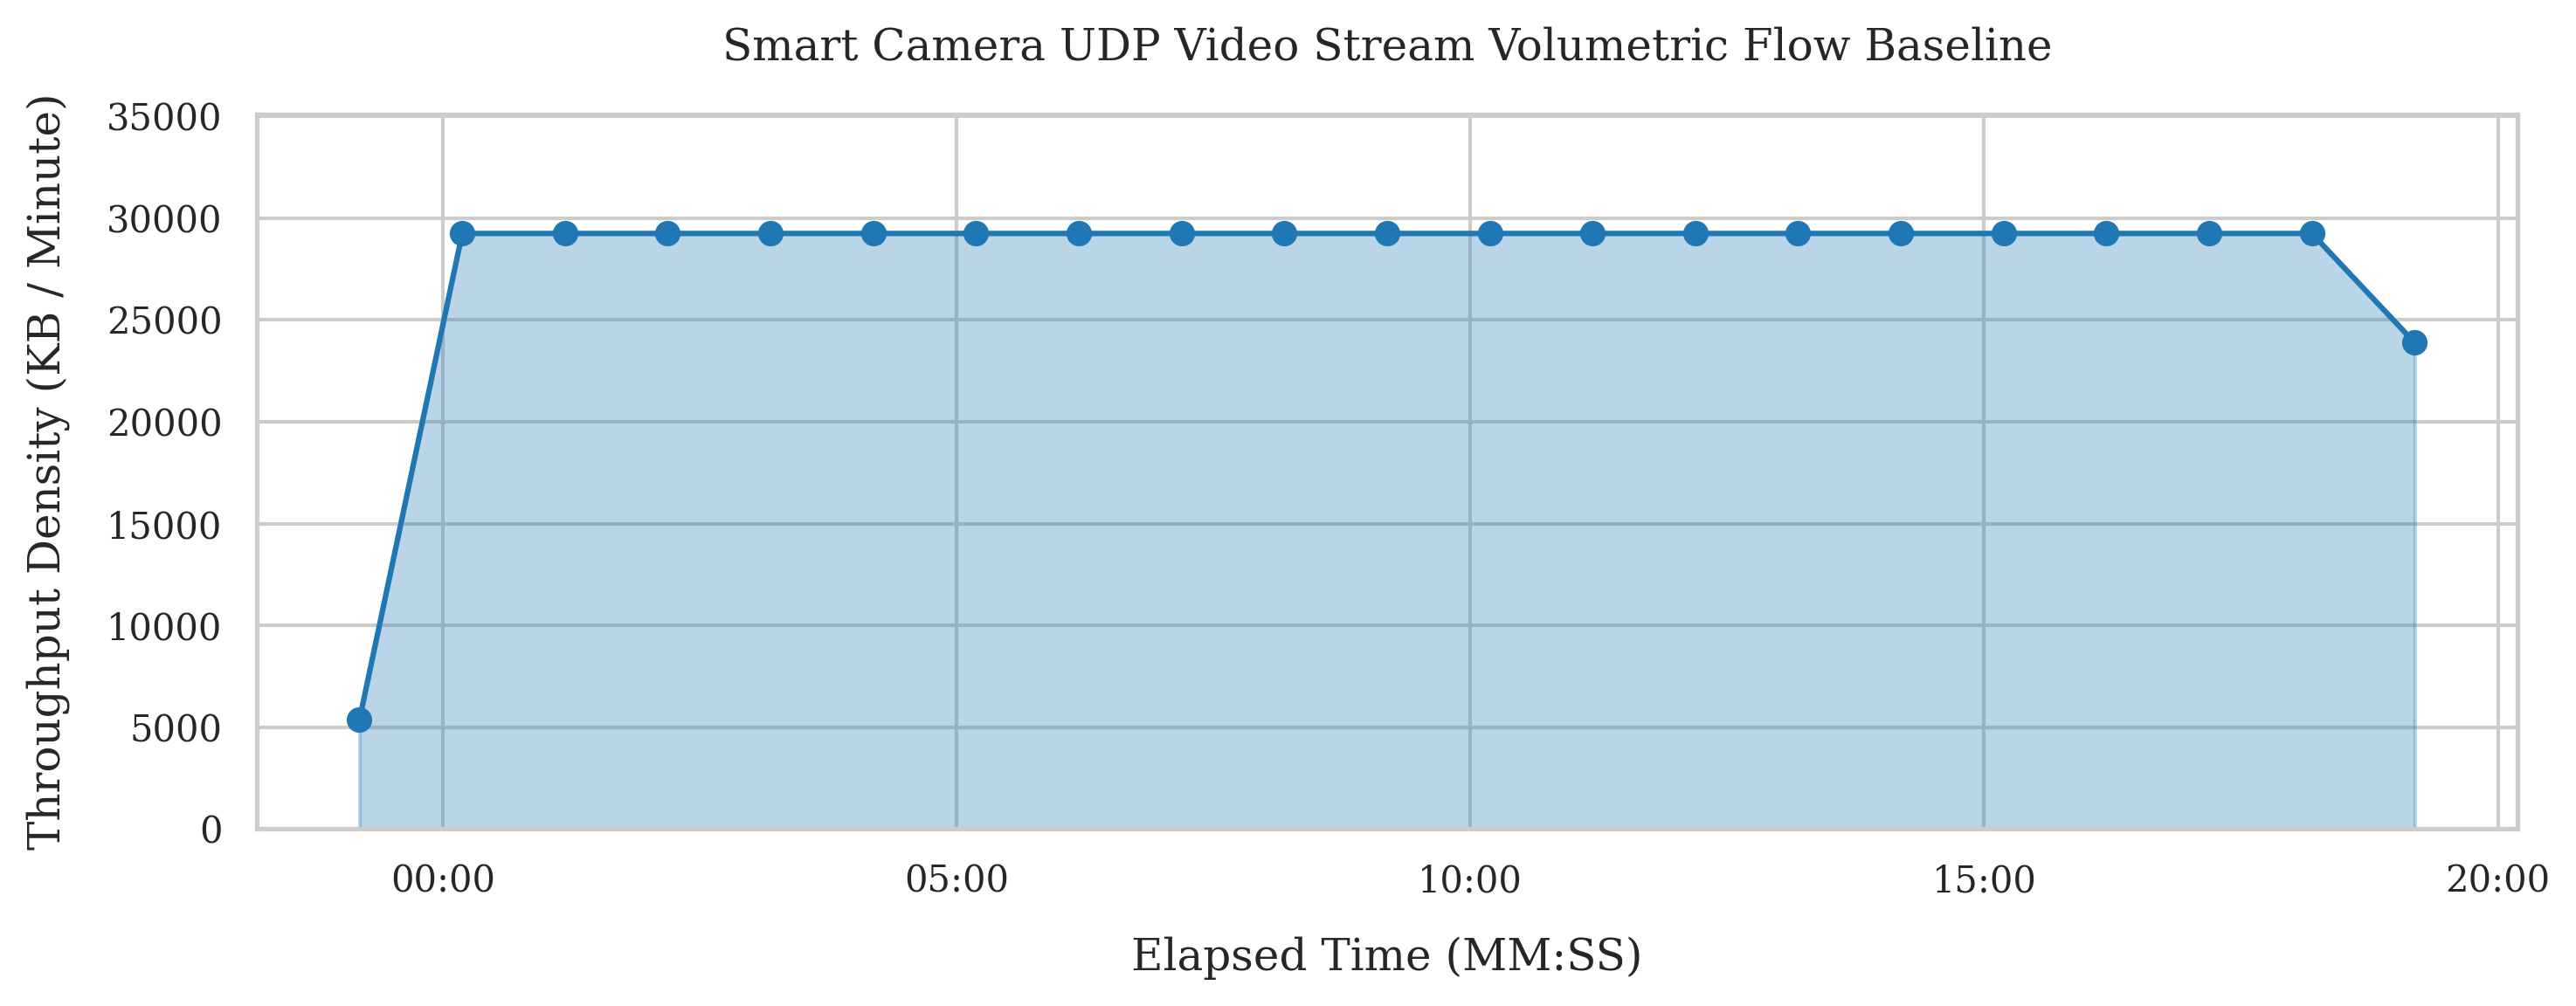

Empirical Average Bandwidth: 27,858.47 KB/minute
Target Bandwidth (4000K):       29,296.88 KB/minute


In [4]:
# Isolate the Camera UDP Feed
camera_udp = conn_df[(conn_df['id.orig_h'] == '10.0.0.1') & 
                     (conn_df['id.resp_p'] == 50005) & 
                     (conn_df['proto'] == 'udp')].copy()

# Fix Mininet 'any' interface double-counting for stateless UDP
camera_udp['orig_bytes'] = camera_udp['orig_bytes'] / 2

total_bytes = camera_udp['orig_bytes'].sum()
print(f"Camera Stream Total Originated Bytes: {total_bytes:,.0f} Bytes")

# ==========================================
# Universal Forensic Data Distribution
# ==========================================
# Get the global start and end of the entire capture
capture_start = conn_df.index.min()
capture_end = conn_df.index.max()

# Create a blank, continuous 1-second timeline for the whole capture
timeline = pd.Series(0.0, index=pd.date_range(start=capture_start, end=capture_end, freq='1s'))

# Dynamically distribute the bytes for EVERY row Zeek logged
for flow_start, row in camera_udp.iterrows():
    raw_duration = row['duration']
    
    # Safely extract duration handling NaNs and Timedeltas
    if pd.isna(raw_duration):
        duration_sec = 1.0
    elif isinstance(raw_duration, pd.Timedelta):
        duration_sec = raw_duration.total_seconds()
    else:
        duration_sec = float(raw_duration)
        
    if duration_sec <= 0: duration_sec = 1.0 # Prevent division by zero
        
    # Calculate bytes per second for this specific Zeek row
    bytes_per_sec = row['orig_bytes'] / duration_sec
    flow_end = flow_start + pd.Timedelta(seconds=duration_sec)
    
    # Slice the timeline and inject the bandwidth
    active_window = (timeline.index >= flow_start) & (timeline.index < flow_end)
    timeline.loc[active_window] += bytes_per_sec

# Resample our distributed 1-second timeline into 1-minute bins
volume_over_time = timeline.resample('1min').sum()


def parse_kbit_rate(rate: str) -> int:
    value = rate.strip().lower()
    if value.endswith('k'):
        return int(float(value[:-1]) * 1000)
    if value.endswith('m'):
        return int(float(value[:-1]) * 1000 * 1000)
    return int(float(value))

def expected_kb_per_min(rate: str) -> float:
    rate_bps = parse_kbit_rate(rate)
    return (rate_bps / 8.0) / 1024.0 * 60.0

# ==========================================
# Plotting (With Elapsed Time Fix)
# ==========================================
fig, ax = plt.subplots(figsize=(10, 4))
kb_values = volume_over_time.values / 1024

# Shift the timestamps so the graph starts at elapsed time 00:00
elapsed_time_index = volume_over_time.index - capture_start + pd.to_datetime('1970-01-01')

# Plot the area chart
ax.fill_between(elapsed_time_index, kb_values, color='#1f77b4', alpha=0.3)
ax.plot(elapsed_time_index, kb_values, marker='o', linestyle='-', color='#1f77b4', linewidth=1.5)

ax.set_title("Smart Camera UDP Video Stream Volumetric Flow Baseline", pad=15)
ax.set_xlabel("Elapsed Time (MM:SS)", labelpad=10)
ax.set_ylabel("Throughput Density (KB / Minute)", labelpad=10)

# Format the X-axis for elapsed minutes and seconds
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%M:%S'))

# Give the chart breathing room on top, handle edge cases if data is 0
top_limit = max(kb_values) * 1.2 if max(kb_values) > 0 else 1000
ax.set_ylim(bottom=0, top=top_limit) 

plt.tight_layout()
save_figure(fig, "camera_volumetric_flow")

plt.show()

# Print empirical average to terminal
avg_kb_min = kb_values[kb_values > 0].mean() if len(kb_values[kb_values > 0]) > 0 else 0
target_kb_min = expected_kb_per_min("4000K")
print(f"Empirical Average Bandwidth: {avg_kb_min:,.2f} KB/minute")
print(f"Target Bandwidth (4000K):       {target_kb_min:,.2f} KB/minute")

### Camera TLS Telemetry and Network Services
We check how often the camera phones home and how often support services run.

* Camera TLS: 5 check-ins.
* NTP: 6 syncs.
* DNS: 42 lookups.

In [5]:
# ==========================================
# INFRASTRUCTURE & BACKGROUND SERVICES VALIDATION
# ==========================================

# Camera TLS Telemetry Verification
camera_tls = conn_df[
    (conn_df['id.orig_h'] == '10.0.0.1') & 
    (conn_df['id.resp_p'] == 443) & 
    (conn_df['proto'] == 'tcp')
]
assert len(camera_tls) == 5, f"CRITICAL baseline failure: Expected 5 TLS flows, found {len(camera_tls)}"
print("Camera TLS Telemetry Validated: Exactly 5 Flows detected (300s interval heartbeat, inclusive of t=0).")

# Network Services (NTP) Verification
ntp_flows = conn_df[
    (conn_df['id.orig_h'].isin(['10.0.0.1', '10.0.0.2'])) & 
    (conn_df['id.resp_p'] == 123) & 
    (conn_df['proto'] == 'udp')
]
assert len(ntp_flows) == 6, f"CRITICAL baseline failure: Expected 6 NTP flows, found {len(ntp_flows)}"
camera_ntp = len(ntp_flows[ntp_flows['id.orig_h'] == '10.0.0.1'])
therm_ntp = len(ntp_flows[ntp_flows['id.orig_h'] == '10.0.0.2'])
print(f"NTP Synchronization Validated: Total 6 Flows ({camera_ntp} Camera, {therm_ntp} Thermostat).")

# Domain Name Resolution (DNS) Verification
dns_queries = dns_df[dns_df['id.orig_h'].isin(['10.0.0.1', '10.0.0.2'])]
assert len(dns_queries) == 42, f"CRITICAL baseline failure: Expected 42 DNS queries, found {len(dns_queries)}"
camera_dns = len(dns_queries[dns_queries['id.orig_h'] == '10.0.0.1'])
therm_dns = len(dns_queries[dns_queries['id.orig_h'] == '10.0.0.2'])
print(f"DNS Queries Validated: Total 42 Queries ({camera_dns} Camera, {therm_dns} Thermostat).")

Camera TLS Telemetry Validated: Exactly 5 Flows detected (300s interval heartbeat, inclusive of t=0).
NTP Synchronization Validated: Total 6 Flows (3 Camera, 3 Thermostat).
DNS Queries Validated: Total 42 Queries (21 Camera, 21 Thermostat).


### Camera Traffic Balance
We compare the camera outgoing bytes with the bytes it receives.

Normal traffic should be mostly outgoing. A big rise in incoming traffic can signal unusual control or remote access.

This check still works even if the capture duplicates some bytes.

In [6]:
# ==========================================
# Camera Directional Byte Ratio Analysis
# ==========================================

# Isolate all connections initiated by the Camera
camera_flows = conn_df[conn_df['id.orig_h'] == '10.0.0.1'].copy()

# Sum the Outbound (orig) and Inbound (resp) bytes securely
outbound_bytes = camera_flows['orig_bytes'].fillna(0).sum()
inbound_bytes = camera_flows['resp_bytes'].fillna(0).sum()
total_bytes = outbound_bytes + inbound_bytes

# Calculate the percentage distribution
if total_bytes > 0:
    outbound_ratio = (outbound_bytes / total_bytes) * 100
    inbound_ratio = (inbound_bytes / total_bytes) * 100
else:
    outbound_ratio = 0
    inbound_ratio = 0

# Professional Output Report
print("=== CAMERA DIRECTIONAL BYTE RATIO ===")
print(f"Total Traffic Volume: {total_bytes:,.0f} Bytes\n")

print(f"Outbound Transmitted (orig_bytes): {outbound_bytes:,.0f} Bytes ({outbound_ratio:.4f}%)")
print(f"Inbound Received (resp_bytes):     {inbound_bytes:,.0f} Bytes ({inbound_ratio:.4f}%)\n")

# Automated Tripwire
if outbound_ratio > 99.0:
    print("Baseline Validated: Traffic is highly asymmetric (>99% outbound), proving normal transmitter behavior.")
else:
    print("FORENSIC ALERT: High inbound volume detected! Potential Reverse Shell or C2 interaction.")

=== CAMERA DIRECTIONAL BYTE RATIO ===
Total Traffic Volume: 1,198,143,151 Bytes

Outbound Transmitted (orig_bytes): 1,198,140,463 Bytes (99.9998%)
Inbound Received (resp_bytes):     2,688 Bytes (0.0002%)

Baseline Validated: Traffic is highly asymmetric (>99% outbound), proving normal transmitter behavior.


## Thermostat Behavior

### Keep-Alives and Telemetry
We separate small keep-alives from larger sensor updates and check that the pattern stays regular.

If that pattern changes, it can point to a problem.

In [7]:
# Isolate for Thermostat MQTT traffic (Enforcing TCP protocol)
thermostat_mqtt = conn_df[
    (conn_df['id.orig_h'] == '10.0.0.2') & 
    (conn_df['id.resp_p'] == 8883) &
    (conn_df['proto'] == 'tcp')
].copy()

# Sort by timestamp (index) to accurately calculate consecutive timing
thermostat_mqtt = thermostat_mqtt.sort_index()

# Separate Keep-Alives from Telemetry using a 20-byte threshold
# Handle NaN values in orig_bytes to prevent accidental row dropping
keep_alives = thermostat_mqtt[thermostat_mqtt['orig_bytes'].fillna(0) < 20].copy()
telemetry = thermostat_mqtt[thermostat_mqtt['orig_bytes'].fillna(0) >= 20].copy()

# ---------------------------------------------------------
# Dynamic Ground Truth Validation (The Fencepost Math)
# ---------------------------------------------------------
# Calculate the exact span of the MQTT capture in seconds
actual_duration = (thermostat_mqtt.index.max() - thermostat_mqtt.index.min()).total_seconds()

keep_alive_interval = 10.0
telemetry_interval = 300.0

# The +1 accounts for the initial packet sent at t=0
expected_keep_alives = int(actual_duration / keep_alive_interval) + 1
expected_telemetry = int(actual_duration / telemetry_interval) + 1

# Assertions with a +/- 2 packet tolerance for virtualization boundary timing
assert abs(len(keep_alives) - expected_keep_alives) <= 2, f"Expected ~{expected_keep_alives} keep-alives, found {len(keep_alives)}"
assert abs(len(telemetry) - expected_telemetry) <= 2, f"Expected ~{expected_telemetry} telemetry flows, found {len(telemetry)}"

print("=== MQTT BEHAVIORAL VALIDATION ===")
print(f"Empirical MQTT Capture Span: {actual_duration:.2f} seconds\n")
print(f"Keep-Alives Validated: {len(keep_alives)} Flows (Target: ~{expected_keep_alives})")
print(f"Telemetry Validated:   {len(telemetry)} Flows (Target: ~{expected_telemetry})\n")

# ---------------------------------------------------------
# Inter-Arrival Time (IAT) Calculation
# ---------------------------------------------------------
# Calculate time difference between consecutive keep-alive rows
keep_alives['IAT'] = keep_alives.index.to_series().diff().dt.total_seconds()

# CRITICAL FIX: Drop the first row's NaN IAT before doing statistical math
iat_clean = keep_alives['IAT'].dropna()

iat_mean = iat_clean.mean()
iat_var = iat_clean.var()

print("--- Temporal Fingerprint (Keep-Alives) ---")
print(f"IAT Mean:     {iat_mean:.4f} seconds")
print(f"IAT Variance: {iat_var:.6f}")

=== MQTT BEHAVIORAL VALIDATION ===
Empirical MQTT Capture Span: 1200.07 seconds

Keep-Alives Validated: 121 Flows (Target: ~121)
Telemetry Validated:   5 Flows (Target: ~5)

--- Temporal Fingerprint (Keep-Alives) ---
IAT Mean:     10.0000 seconds
IAT Variance: 0.000003


### Keep-Alive Timing
We plot the time between keep-alives to see if they arrive on a steady schedule.

A stable baseline should look tight and regular.

<>:29: SyntaxWarning: invalid escape sequence '\D'
<>:29: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_17266/3516792100.py:29: SyntaxWarning: invalid escape sequence '\D'
  ax.set_ylabel("Inter-Arrival Time $\Delta t$ (Seconds)", labelpad=10)


Saved figure: ../../figures/scenario2/thermostat_iat_distribution.pdf and ../../figures/scenario2/thermostat_iat_distribution.png


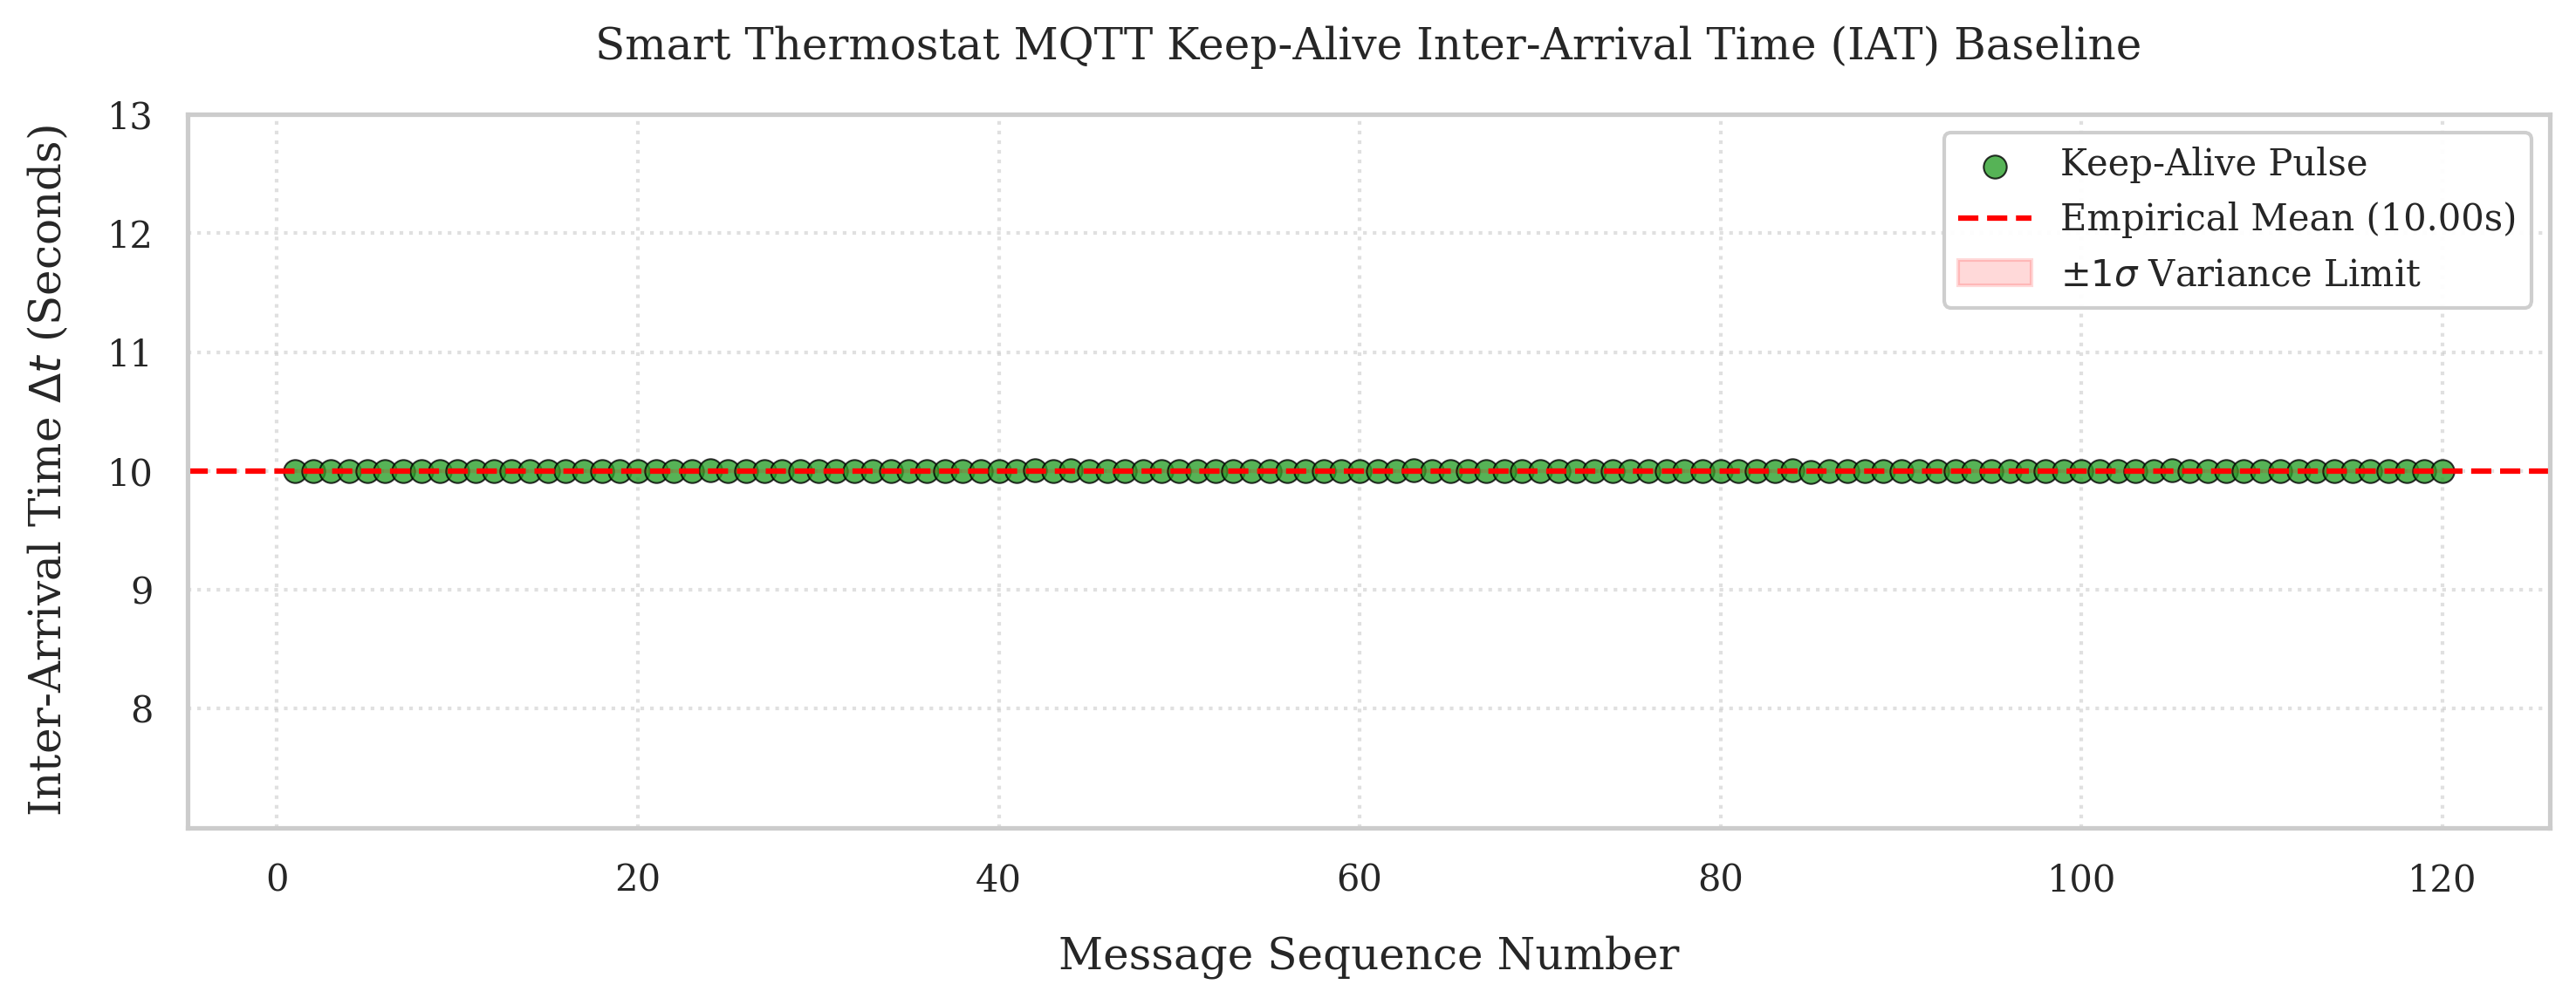

IAT Scatter Plot Generated.
   - Mapped 120 sequential pulses.
   - Empirical Mean: 10.0000s | Standard Deviation: 0.0016s


In [8]:
# Clean the NaN value from the first row (the initial fencepost packet)
plot_data = keep_alives.dropna(subset=['IAT']).copy()

# Re-sequence from 1 to N after dropping the first row
plot_data['Sequence'] = range(1, len(plot_data) + 1)

# Calculate plotting statistics
iat_mean = plot_data['IAT'].mean()
iat_std = plot_data['IAT'].std()

# Academic Plotting
fig, ax = plt.subplots(figsize=(10, 4))

# Plot the individual IAT events
ax.scatter(plot_data['Sequence'], plot_data['IAT'], 
           color='#2ca02c', alpha=0.8, edgecolors='black', linewidth=0.5, s=40, label='Keep-Alive Pulse')

# Plot the empirical mean
ax.axhline(y=iat_mean, color='red', linestyle='--', linewidth=1.5, label=f"Empirical Mean ({iat_mean:.2f}s)")

# Add a shaded band for +/- 1 Standard Deviation to visually prove the near-zero variance
ax.fill_between(plot_data['Sequence'], 
                iat_mean - iat_std, 
                iat_mean + iat_std, 
                color='red', alpha=0.15, label=r'$\pm 1\sigma$ Variance Limit')

ax.set_title("Smart Thermostat MQTT Keep-Alive Inter-Arrival Time (IAT) Baseline", pad=15)
ax.set_xlabel("Message Sequence Number", labelpad=10)
ax.set_ylabel("Inter-Arrival Time $\Delta t$ (Seconds)", labelpad=10)

# Add a subtle grid to make temporal deviations easy to spot
ax.grid(True, linestyle=':', alpha=0.6)

# Focus the Y-axis tightly around the expected baseline to highlight stability
ax.set_ylim(bottom=max(0, iat_mean - 3), top=iat_mean + 3) 

# Place the legend neatly in the corner
ax.legend(loc="upper right", framealpha=0.95)

plt.tight_layout()
save_figure(fig, "thermostat_iat_distribution")

plt.show()

print(f"IAT Scatter Plot Generated.")
print(f"   - Mapped {len(plot_data)} sequential pulses.")
print(f"   - Empirical Mean: {iat_mean:.4f}s | Standard Deviation: {iat_std:.4f}s")

### Telemetry Size
We measure how large the thermostat sensor messages are.

They should stay close in size, and a big change could mean something is off.

In [9]:
# ==========================================
# Thermostat Telemetry Payload Footprinting
# ==========================================

# Extract the byte sizes of the telemetry packets (>= 20 bytes)
# We use the 'telemetry' dataframe previously generated in the IAT cell
payload_sizes = telemetry['orig_bytes'].dropna()

# Calculate the statistical footprint
payload_mean = payload_sizes.mean()

# Variance requires at least 2 packets. If identical, variance is mathematically 0.0
payload_var = payload_sizes.var() if len(payload_sizes) > 1 else 0.0

# Min/Max boundary detection
payload_min = payload_sizes.min()
payload_max = payload_sizes.max()

# Professional Output Report
print("=== MQTT TELEMETRY PAYLOAD FOOTPRINT ===")
print(f"Total Telemetry Reports Analyzed: {len(payload_sizes)}\n")

print(f"Empirical Mean Size: {payload_mean:.2f} Bytes")
print(f"Payload Variance:    {payload_var:.4f}")
print(f"Observed Range:      {payload_min:.0f} Bytes to {payload_max:.0f} Bytes\n")

# Automated Tripwire
# A variance of less than 5 indicates extreme structural rigidity (expected for M2M)
if payload_var < 5.0:
    print("Baseline Validated: Telemetry payloads are structurally rigid and predictable.")
else:
    print("FORENSIC ALERT: High payload variance detected! Potential data exfiltration or payload stuffing.")

=== MQTT TELEMETRY PAYLOAD FOOTPRINT ===
Total Telemetry Reports Analyzed: 5

Empirical Mean Size: 27.00 Bytes
Payload Variance:    0.0000
Observed Range:      27 Bytes to 27 Bytes

Baseline Validated: Telemetry payloads are structurally rigid and predictable.


## Network Health

### TCP Connection States
We look at the main TCP states to see whether the network is behaving normally.

Clean traffic should mostly show normal connections.

Saved figure: ../../figures/scenario2/tcp_connection_states.pdf and ../../figures/scenario2/tcp_connection_states.png


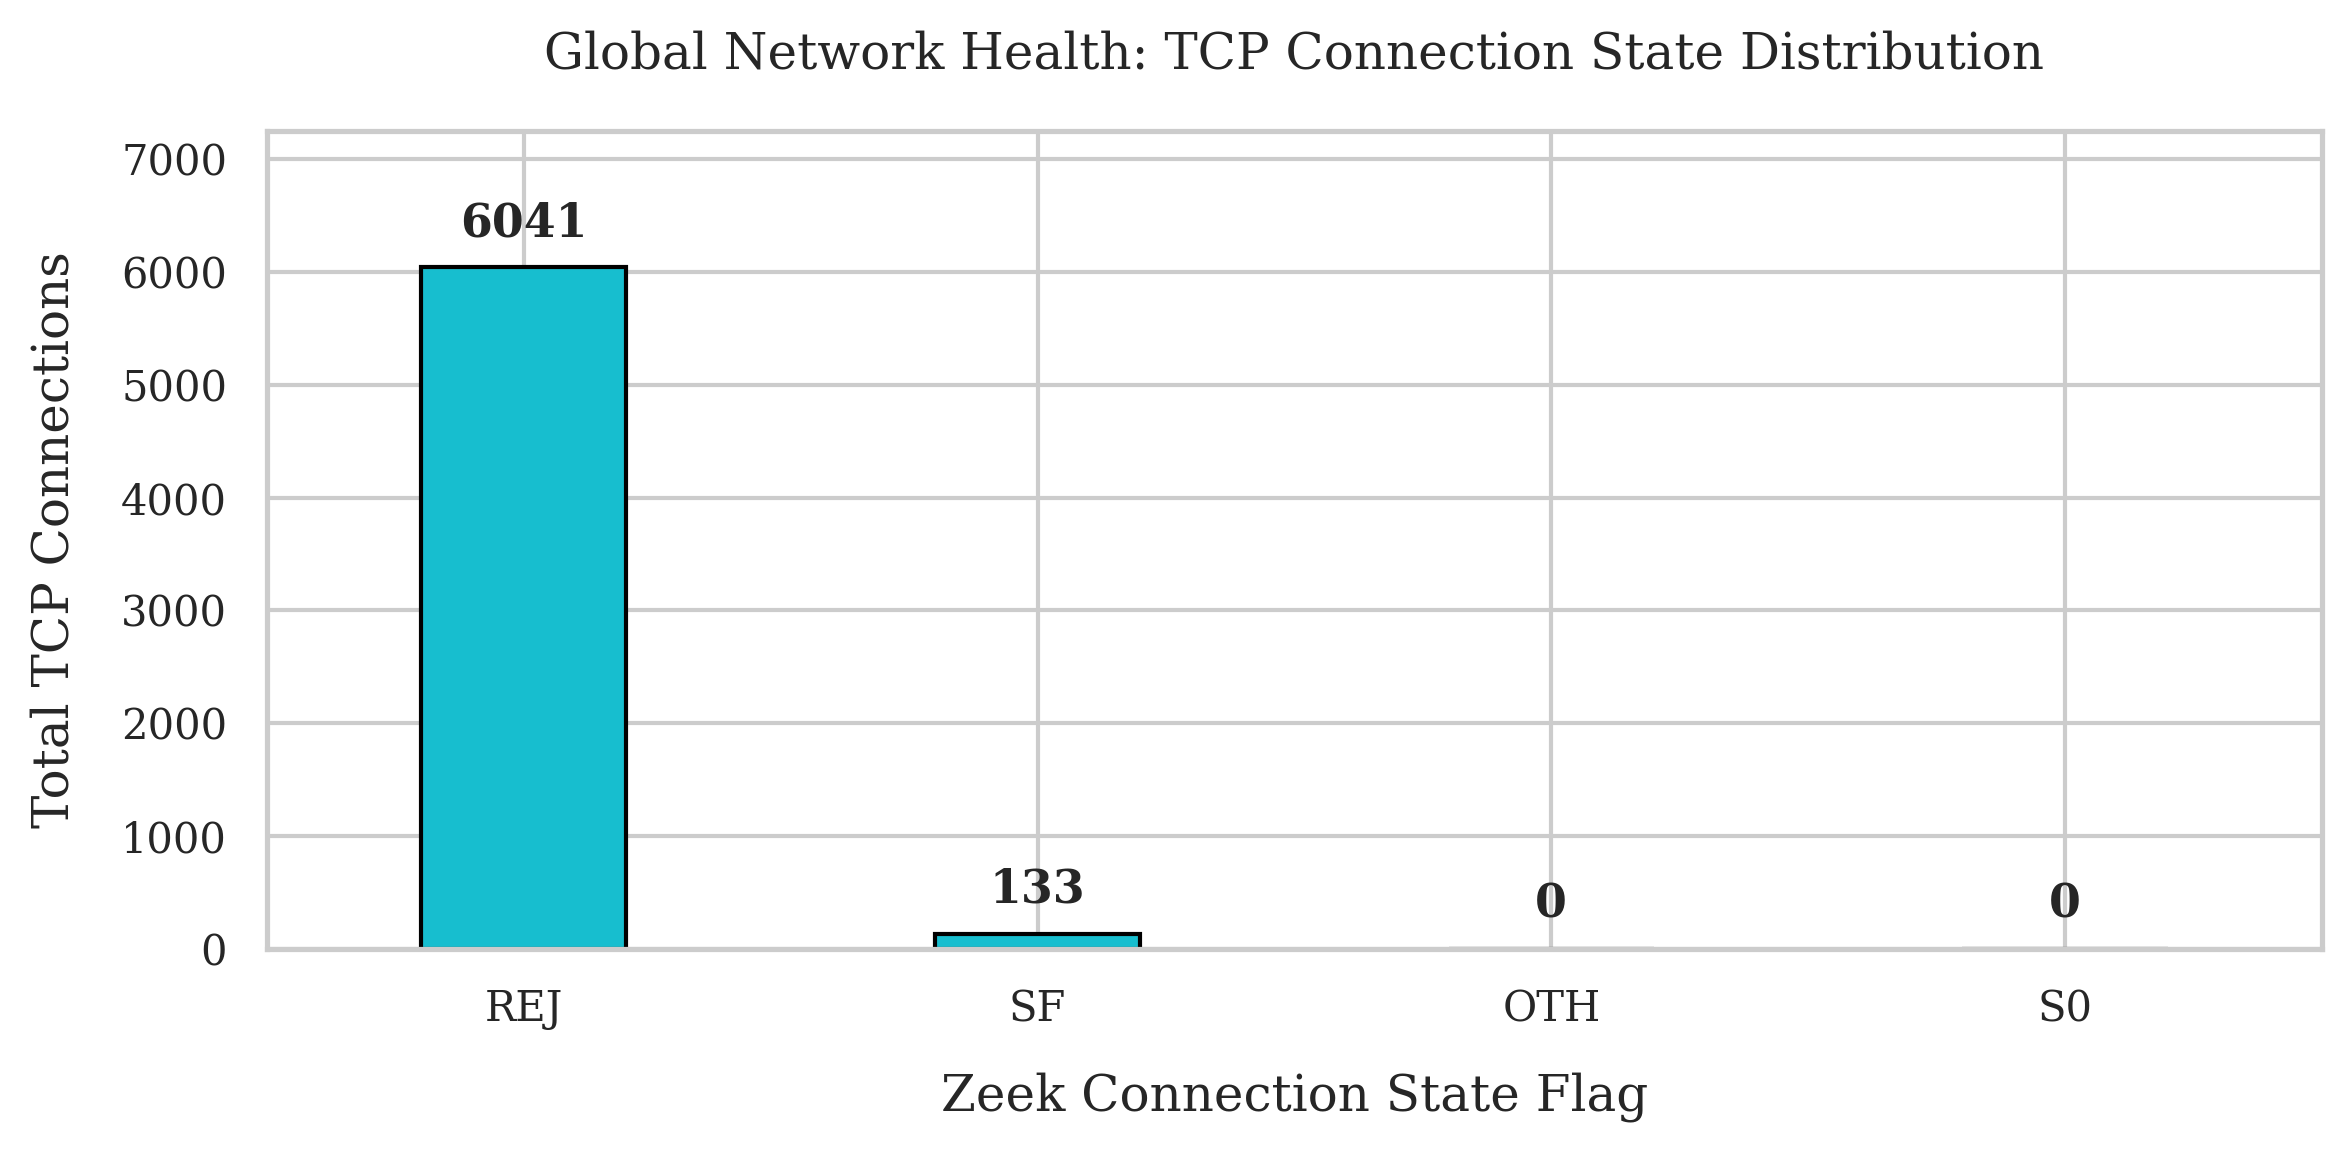

=== TCP STATE FORENSIC REPORT ===
Total TCP Flows Analyzed: 6174

[REJ] : 6,041 Flows -> Connection attempt rejected by responder (RST sent).
[SF] : 133 Flows -> Normal establishment and termination (Clean Teardown).
[OTH] : 0 Flows -> No SYN seen, just mid-stream traffic (Asymmetric routing).
[S0] : 0 Flows -> Connection attempt seen, no reply (Scanner / Blocked).


In [10]:
# ==========================================
# 5.1 Global Network Health (TCP States)
# ==========================================

# Isolate ONLY TCP traffic
tcp_df = conn_df[conn_df['proto'] == 'tcp'].copy()

# Compute state distribution
state_counts = tcp_df['conn_state'].value_counts()

# Academic Plotting
fig, ax = plt.subplots(figsize=(8, 4)) # Slightly wider to accommodate labels

# Use a distinct color palette
state_counts.plot(kind='bar', color='#17becf', ax=ax, width=0.4, edgecolor='black')

ax.set_title("Global Network Health: TCP Connection State Distribution", pad=15)
ax.set_xlabel("Zeek Connection State Flag", labelpad=10)
ax.set_ylabel("Total TCP Connections", labelpad=10)

# Explicitly set the x-axis limits to give a single bar breathing room
ax.set_xlim(-0.5, len(state_counts) - 0.5)
plt.xticks(rotation=0)

# Bulletproof text annotation layer
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}',
                xy=(p.get_x() + p.get_width() / 2, height),
                xytext=(0, 5),  # 5 points vertical offset
                textcoords="offset points",
                ha='center', va='bottom', fontsize=11, weight='bold')

# Ensure the Y-axis has room for the top annotation
ax.set_ylim(0, state_counts.max() * 1.2)

plt.tight_layout()
save_figure(fig, "tcp_connection_states")
plt.show()

# ---------------------------------------------------------
# Automated Contextual Reporting
# ---------------------------------------------------------
# A reference dictionary mapping Zeek states to their physical network reality
zeek_state_definitions = {
    'SF': 'Normal establishment and termination (Clean Teardown).',
    'S0': 'Connection attempt seen, no reply (Scanner / Blocked).',
    'S1': 'Connection established, not terminated (Persistent Socket).',
    'REJ': 'Connection attempt rejected by responder (RST sent).',
    'RSTO': 'Connection established, originator aborted (RST sent).',
    'RSTR': 'Established, responder aborted (RST sent).',
    'OTH': 'No SYN seen, just mid-stream traffic (Asymmetric routing).',
}

print("=== TCP STATE FORENSIC REPORT ===")
print(f"Total TCP Flows Analyzed: {len(tcp_df)}\n")

for state, count in state_counts.items():
    definition = zeek_state_definitions.get(state, "Unknown state.")
    print(f"[{state}] : {count:,.0f} Flows -> {definition}")

### Flow Rate
We count how many new connections appear each minute.

A steady baseline should stay low, while unusual activity should create spikes.

Saved figure: ../../figures/scenario2/network_flow_density.pdf and ../../figures/scenario2/network_flow_density.png


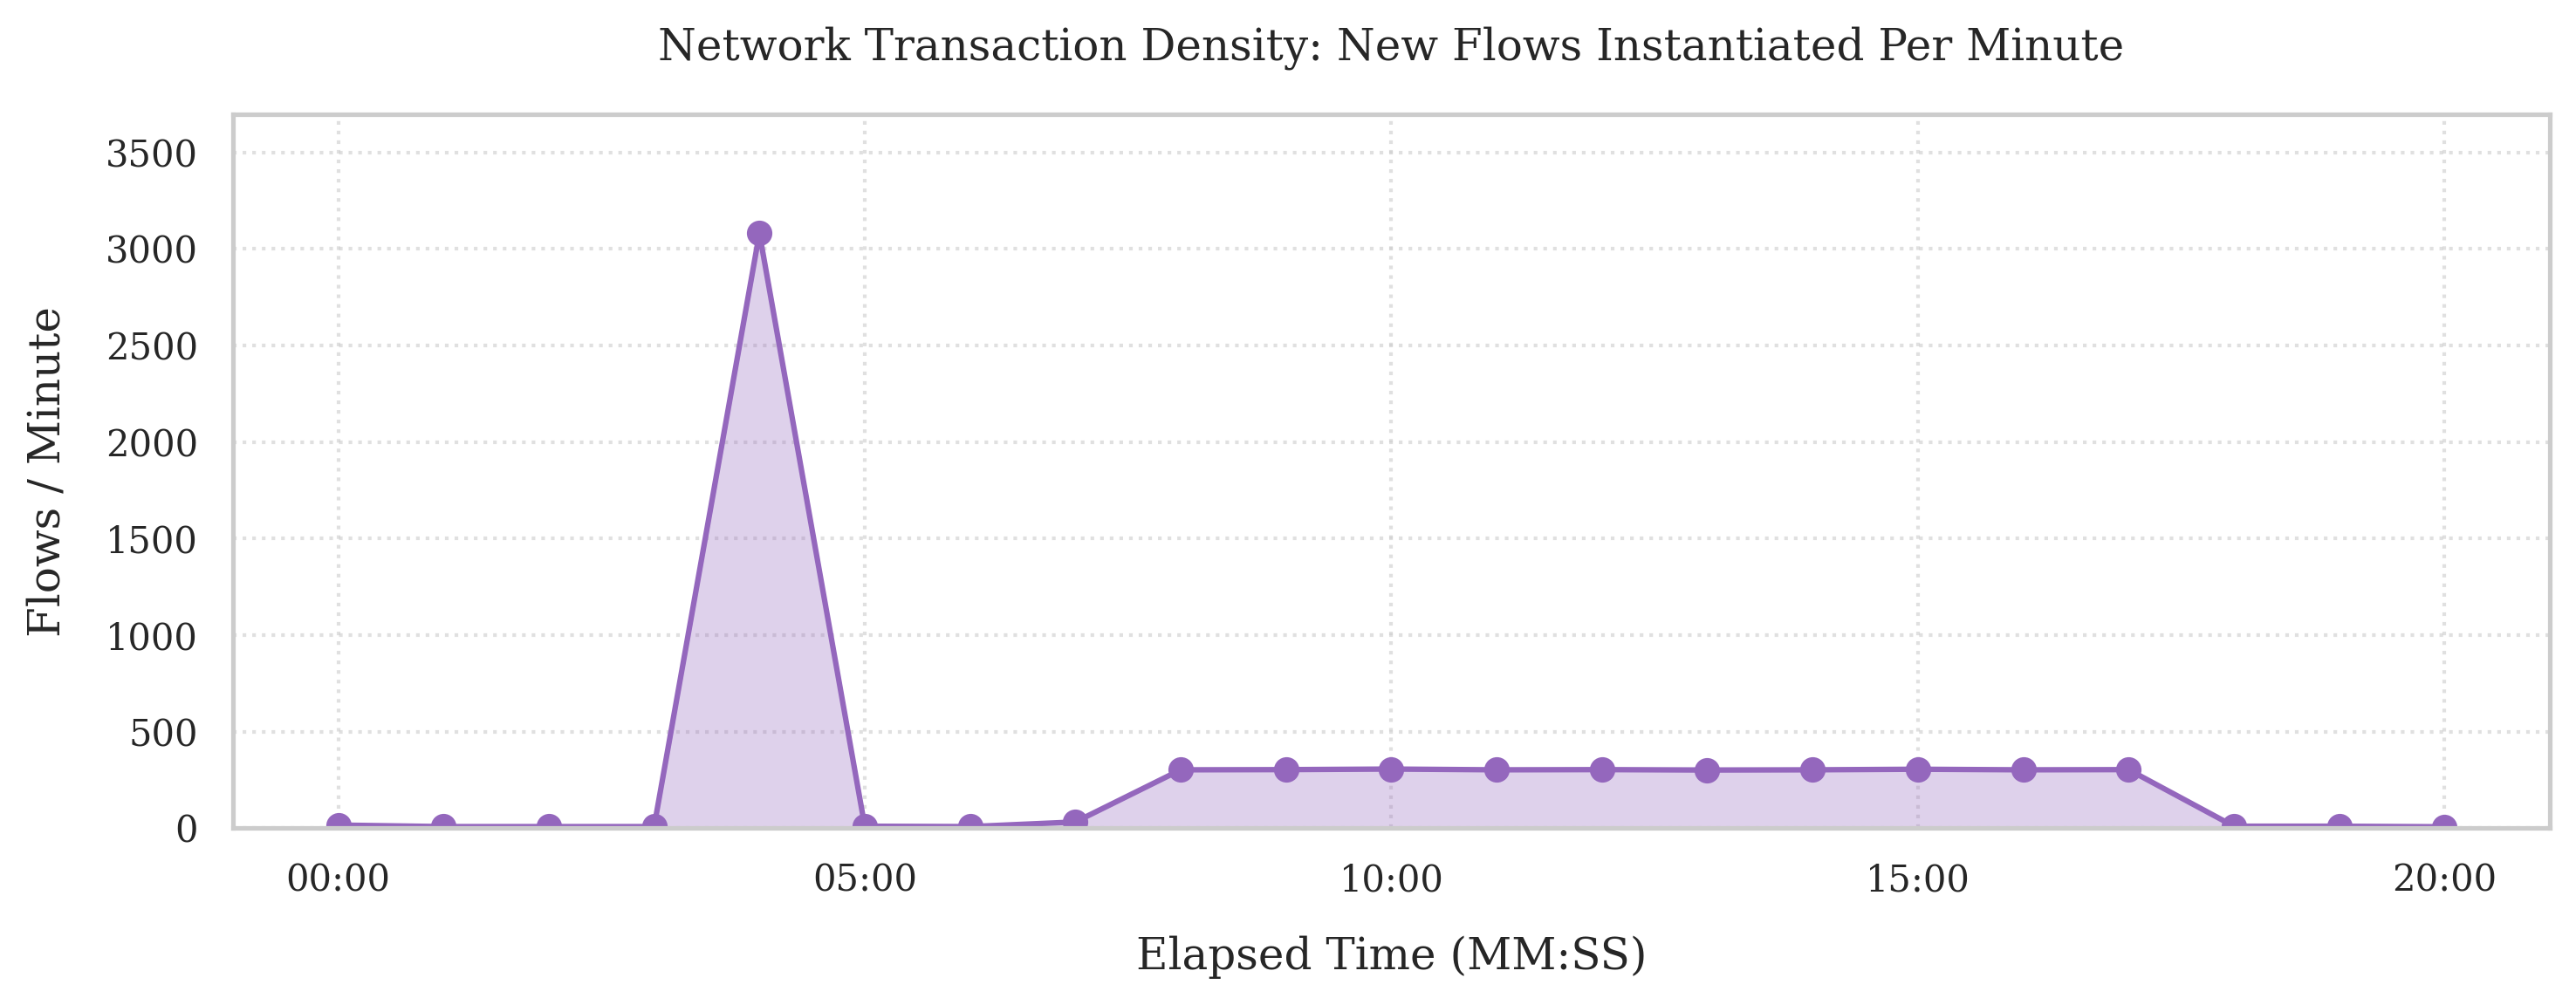

=== NETWORK DENSITY REPORT ===
Average Flows per Minute:      296.52
Peak Flows in a Single Minute: 3081


In [11]:
# ==========================================
# 5.2 Network Density (Flows / Minute)
# ==========================================

# Resample to count total flows per minute.
# origin='start' ensures bins are exactly 60 seconds long starting from the very first packet.
flows_per_minute = conn_df['uid'].resample('1min', origin='start').count()

# Apply the '1970' Elapsed Time trick to cleanly format the X-axis
capture_start = conn_df.index.min()
elapsed_time_index = flows_per_minute.index - capture_start + pd.to_datetime('1970-01-01')

# Academic Plotting
fig, ax = plt.subplots(figsize=(10, 4))

# Using a fill_between area chart visually aligns with your Camera Volumetric graph
ax.fill_between(elapsed_time_index, flows_per_minute.values, color='#9467bd', alpha=0.3)
ax.plot(elapsed_time_index, flows_per_minute.values, color='#9467bd', marker='o', linestyle='-', linewidth=1.5)

ax.set_title("Network Transaction Density: New Flows Instantiated Per Minute", pad=15)
ax.set_xlabel("Elapsed Time (MM:SS)", labelpad=10)
ax.set_ylabel("Flows / Minute", labelpad=10)

# Standard matplotlib formatter (no custom functions required)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%M:%S'))

# Add a subtle grid to help the reader track peaks
ax.grid(True, linestyle=':', alpha=0.6)

# Give the chart breathing room on top
top_limit = flows_per_minute.max() * 1.2 if flows_per_minute.max() > 0 else 10
ax.set_ylim(bottom=0, top=top_limit)

plt.tight_layout()
save_figure(fig, "network_flow_density")
plt.show()

# Contextual Output Report
print("=== NETWORK DENSITY REPORT ===")
print(f"Average Flows per Minute:      {flows_per_minute.mean():.2f}")
print(f"Peak Flows in a Single Minute: {flows_per_minute.max():.0f}")

### Traffic Map
We map which devices talk to each other.

In the baseline, the camera and thermostat should only talk to the gateway, not to each other.

Saved figure: ../../figures/scenario2/topology_traffic_matrix.pdf and ../../figures/scenario2/topology_traffic_matrix.png


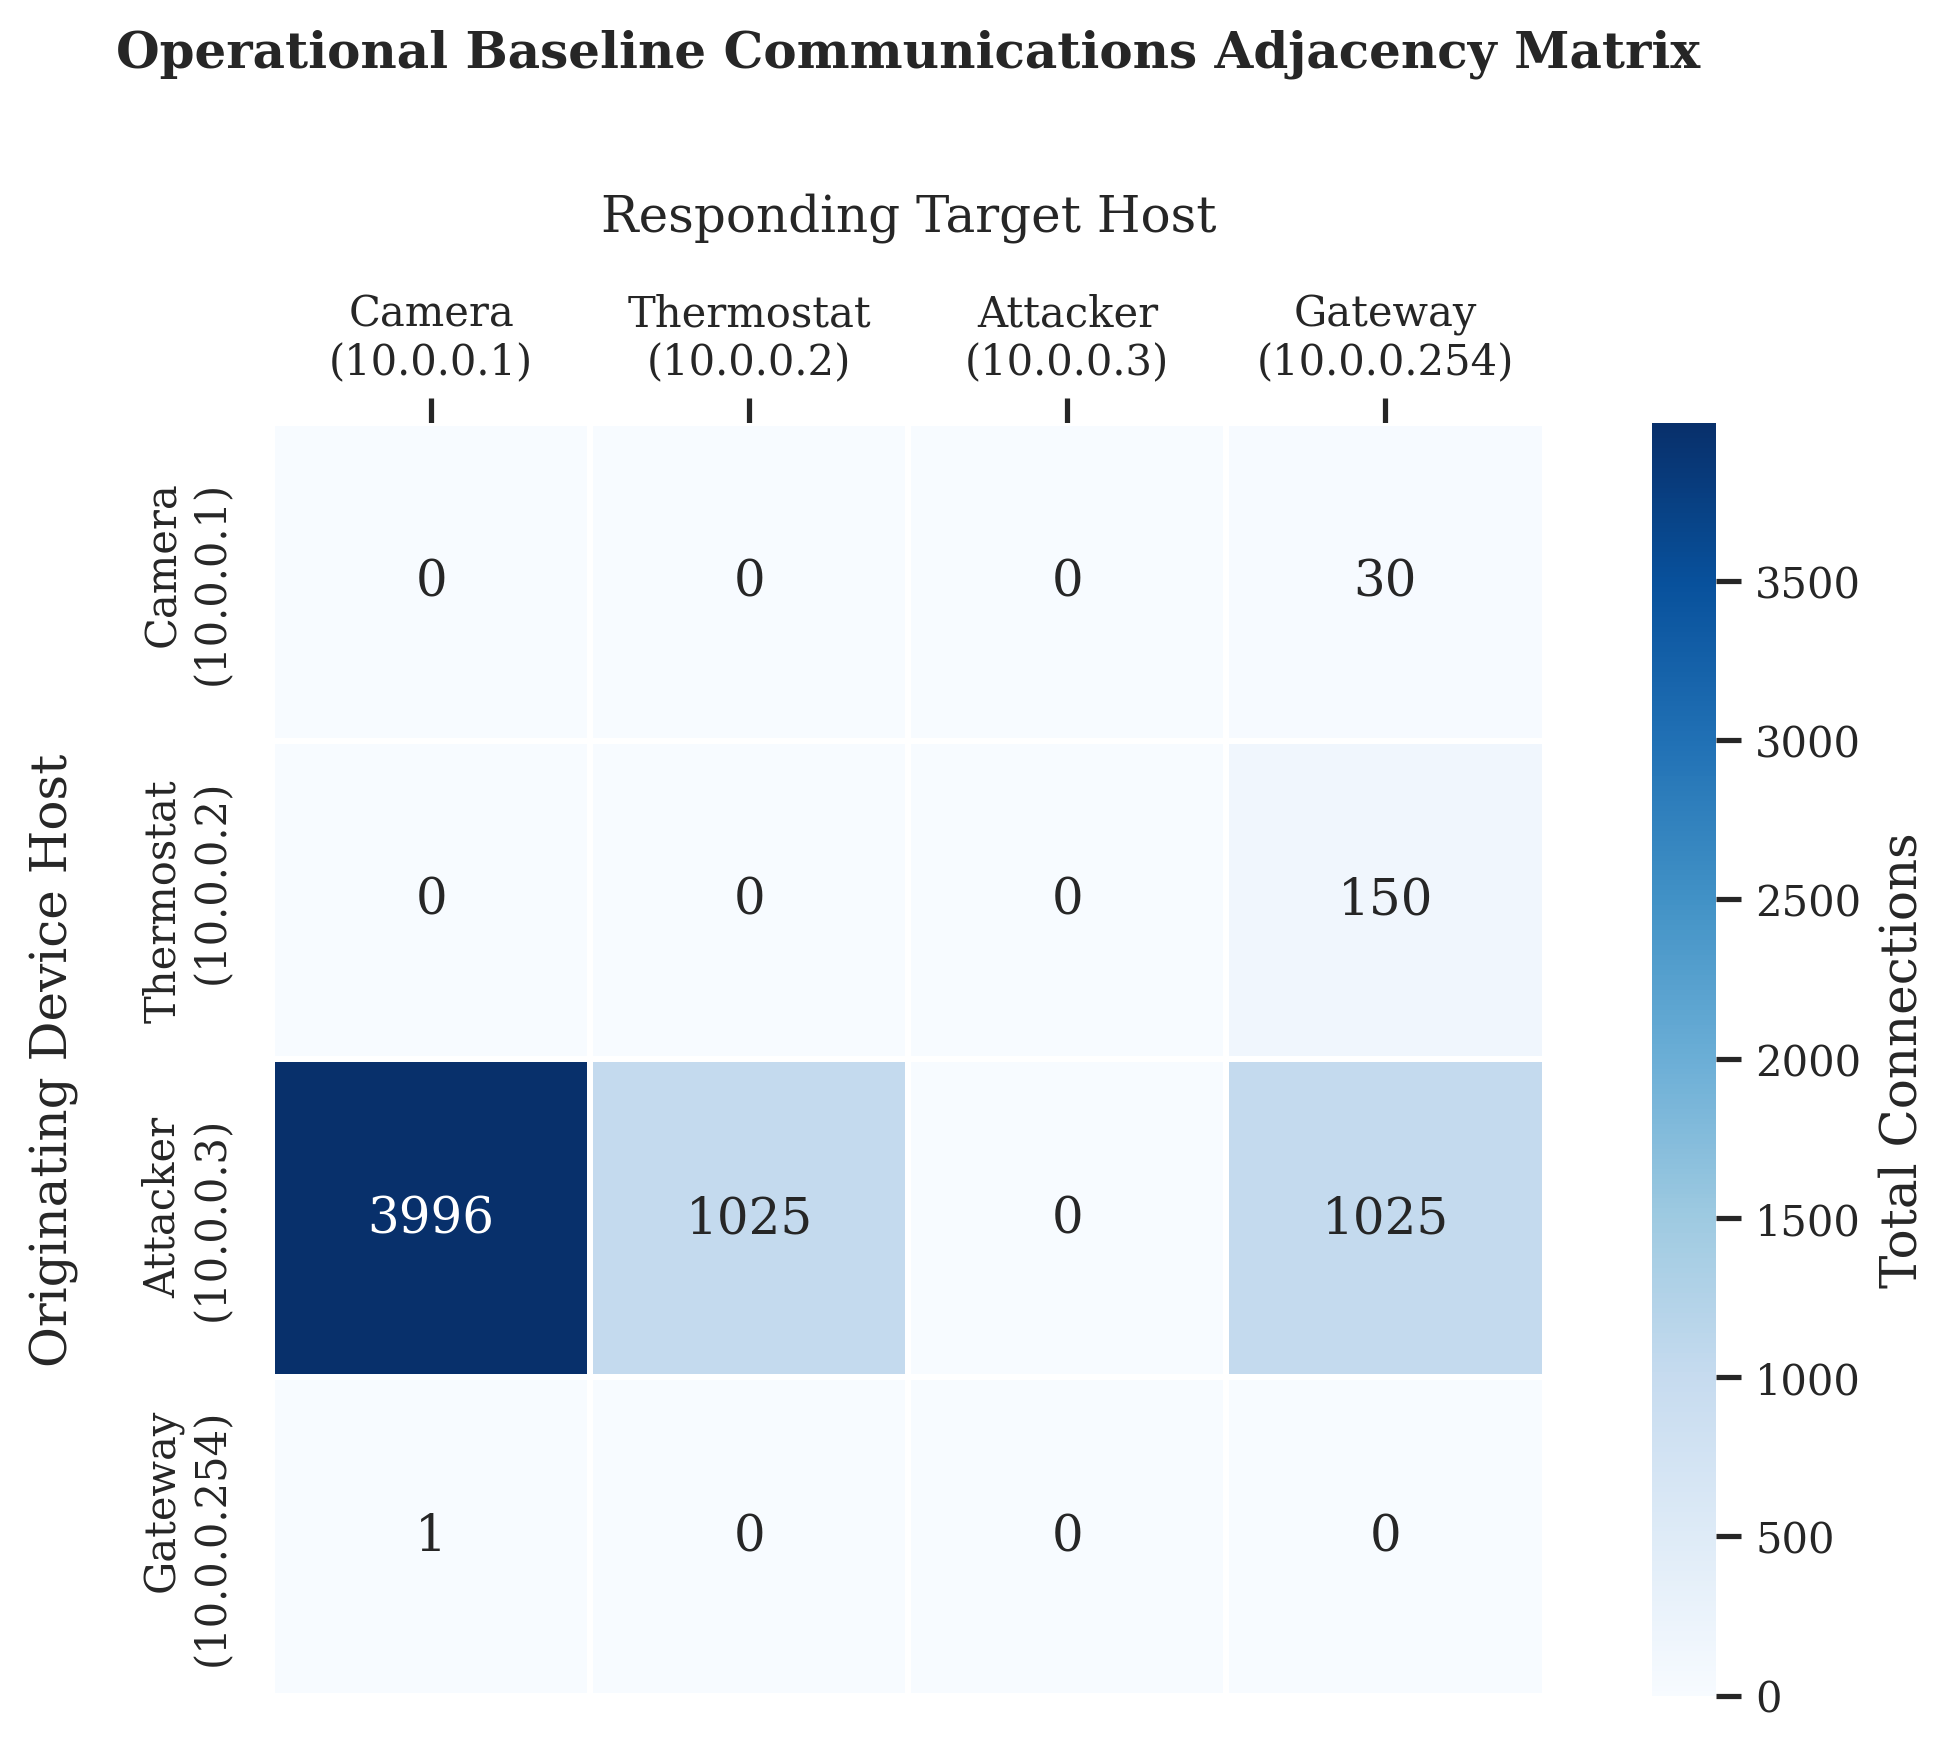

=== TOPOLOGY RULES VALIDATION ===
Zero-Trust Baseline Validated: No lateral communication between IoT edge devices.


In [12]:
# ==========================================
# Topology Matrix (Adjacency Heatmap)
# ==========================================

import pandas as pd

# Build the raw communication matrix
matrix_data = pd.crosstab(conn_df['id.orig_h'].to_numpy(), conn_df['id.resp_h'].to_numpy())

# Ensure all 4 core nodes are represented to protect baseline symmetry
# (target_ips was defined in Cell 1: ['10.0.0.1', '10.0.0.2', '10.0.0.3', '10.0.0.254'])
for ip in target_ips:
    if ip not in matrix_data.index:
        matrix_data.loc[ip] = 0
    if ip not in matrix_data.columns:
        matrix_data[ip] = 0

# Sort logically to build the matrix flow map
matrix_data = matrix_data.reindex(index=target_ips, columns=target_ips).fillna(0)

# CRITICAL UPGRADE: Human-Readable Device Mapping
device_labels = {
    '10.0.0.1': 'Camera\n(10.0.0.1)',
    '10.0.0.2': 'Thermostat\n(10.0.0.2)',
    '10.0.0.3': 'Attacker\n(10.0.0.3)',
    '10.0.0.254': 'Gateway\n(10.0.0.254)'
}

# Rename the axes for the heatmap
matrix_data_labeled = matrix_data.rename(index=device_labels, columns=device_labels)

# Academic Plotting
fig, ax = plt.subplots(figsize=(8, 6))

# Using a custom color map: 'Blues' is great, but we can make it starker for zeros
sns.heatmap(matrix_data_labeled, annot=True, fmt=".0f", cmap="Blues", cbar=True, square=True,
            linewidths=1, linecolor='white', cbar_kws={'label': 'Total Connections'}, ax=ax)

# Move the X-axis labels to the top for a more traditional matrix feel (Optional but looks great)
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top') 

ax.set_title("Operational Baseline Communications Adjacency Matrix", pad=30, weight='bold')
ax.set_xlabel("Responding Target Host", labelpad=15)
ax.set_ylabel("Originating Device Host", labelpad=15)

plt.tight_layout()
save_figure(fig, "topology_traffic_matrix")
plt.show()

# ---------------------------------------------------------
# Automated Lateral Movement Validation
# ---------------------------------------------------------
print("=== TOPOLOGY RULES VALIDATION ===")

# Check if Camera (1) talked to Thermostat (2), or vice versa
cam_to_therm = matrix_data.loc['10.0.0.1', '10.0.0.2']
therm_to_cam = matrix_data.loc['10.0.0.2', '10.0.0.1']
lateral_traffic = cam_to_therm + therm_to_cam

if lateral_traffic == 0:
    print("Zero-Trust Baseline Validated: No lateral communication between IoT edge devices.")
else:
    print(f"FORENSIC ALERT: {lateral_traffic:,.0f} lateral connections detected between Camera and Thermostat!")

### DNS Requests
We track DNS lookups over time to see when devices search for their services.

This also helps spot odd or unexpected lookups.

Saved figure: ../../figures/scenario2/dns_query_timeline.pdf and ../../figures/scenario2/dns_query_timeline.png


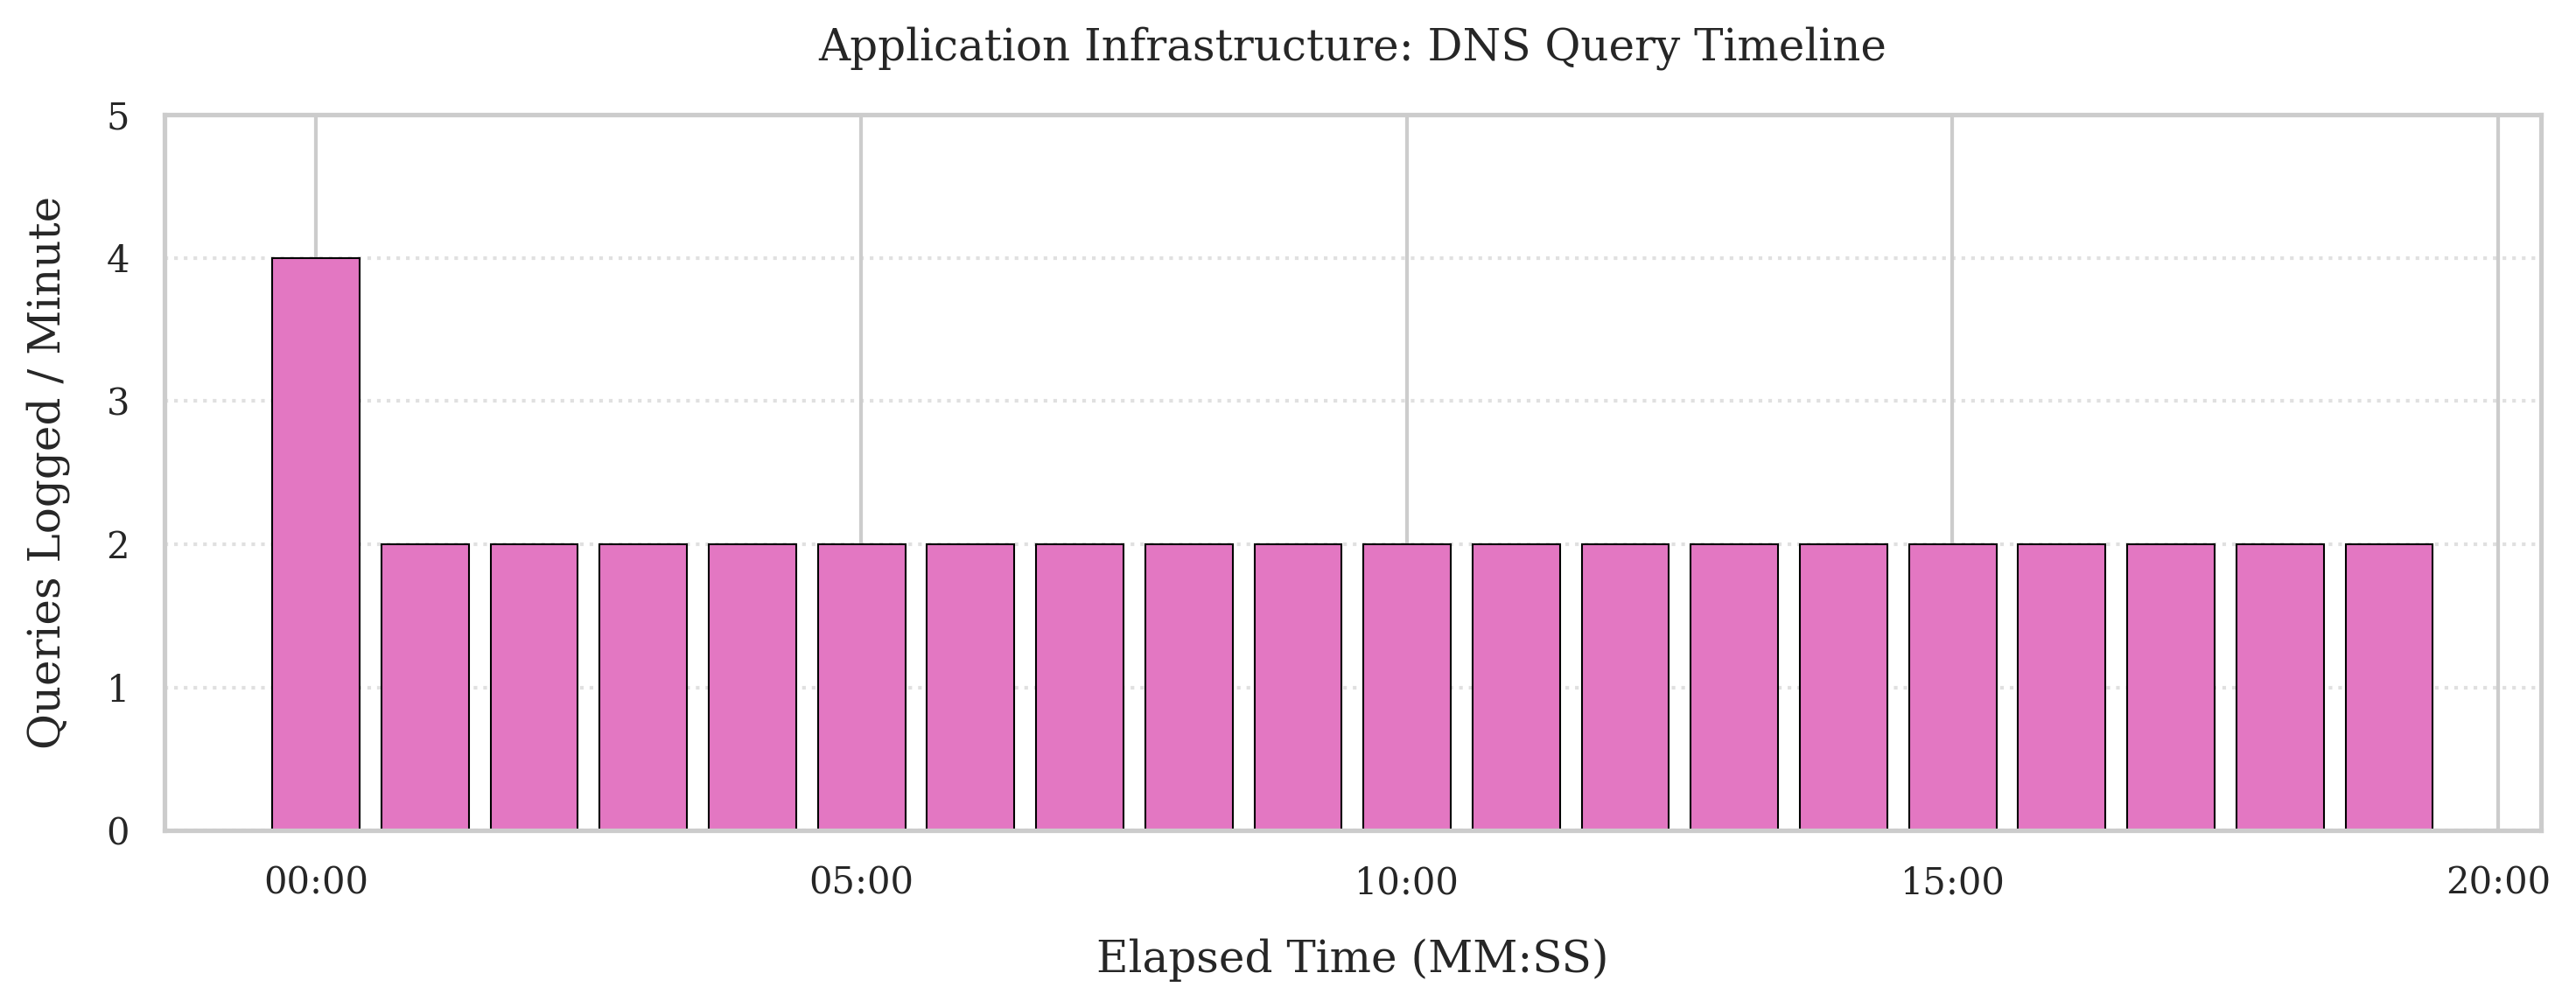

=== DNS QUERY FORENSIC REPORT ===
Total DNS Queries Logged: 42

--- Queried Domains ---
api.smartcamera.com : 21 queries
mqtt.smartthermostat.com : 21 queries

--- Baseline Validation ---
Baseline Validated: 100% of DNS lookups match authorized IoT endpoints.


In [13]:
# ==========================================
# Infrastructure Services (DNS Profiling)
# ==========================================

# Resample DNS query frequency
# CRITICAL FIX: origin='start' prevents wall-clock truncation
dns_frequency = dns_df['uid'].resample('1min', origin='start').count()

# Apply the '1970' Elapsed Time trick
capture_start = conn_df.index.min()
elapsed_time_index = dns_frequency.index - capture_start + pd.to_datetime('1970-01-01')

# Academic Plotting
fig, ax = plt.subplots(figsize=(10, 4))

# For a datetime x-axis, width is calculated in days. 
# 1 minute = 1/(24*60) days. We multiply by 0.8 to leave gaps between bars.
bar_width = (1 / 1440) * 0.8 

ax.bar(elapsed_time_index, dns_frequency.values, width=bar_width, color='#e377c2', edgecolor='black', linewidth=0.5)

ax.set_title("Application Infrastructure: DNS Query Timeline", pad=15)
ax.set_xlabel("Elapsed Time (MM:SS)", labelpad=10)
ax.set_ylabel("Queries Logged / Minute", labelpad=10)

# Standard matplotlib formatter
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%M:%S'))

# Set y-axis to handle the low volume of DNS smoothly (forces integers on Y axis)
ax.yaxis.get_major_locator().set_params(integer=True)
ax.set_ylim(bottom=0, top=max(3, dns_frequency.max() + 1)) 

# Add a subtle grid
ax.grid(True, axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
save_figure(fig, "dns_query_timeline")
plt.show()

# ---------------------------------------------------------
# Automated Domain Resolution Report
# ---------------------------------------------------------
print("=== DNS QUERY FORENSIC REPORT ===")
print(f"Total DNS Queries Logged: {len(dns_df)}\n")

# Check if the 'query' column exists (standard Zeek dns.log feature)
if 'query' in dns_df.columns:
    print("--- Queried Domains ---")
    domain_counts = dns_df['query'].value_counts()
    for domain, count in domain_counts.items():
        print(f"{domain} : {count} queries")
        
    print("\n--- Baseline Validation ---")
    # Tripwire logic: If there are domains other than your 2 authorized ones, throw an alert
    unauthorized_domains = domain_counts[~domain_counts.index.isin(['api.smartcamera.com', 'mqtt.smartthermostat.com'])]
    
    if len(unauthorized_domains) == 0:
        print("Baseline Validated: 100% of DNS lookups match authorized IoT endpoints.")
    else:
        print(f"FORENSIC ALERT: {len(unauthorized_domains)} unauthorized domains requested! Potential DGA or DNS Tunneling.")
else:
    print("ℹ️ Note: 'query' column not found in DataFrame. Ensure Zeek dns.log was parsed correctly.")

### Attacker Recon and Brute Force

We group attacker traffic into discovery, scan, and brute-force phases.

This section summarizes how strong the attack was and when it happened.

In [14]:
# ==========================================
# Attacker Recon + Brute-Force Analysis
# ==========================================

attacker_ip = '10.0.0.3'
camera_ip = '10.0.0.1'

# Isolate any flow involving the attacker
attacker_flows = conn_df[
    (conn_df['id.orig_h'] == attacker_ip) |
    (conn_df['id.resp_h'] == attacker_ip)
].copy()

total_attacker_flows = len(attacker_flows)

# Host discovery is ICMP originating from the attacker
icmp_discovery = attacker_flows[
    (attacker_flows['proto'] == 'icmp') &
    (attacker_flows['id.orig_h'] == attacker_ip)
].copy()

# TCP scan across low ports (exclude the 443 target to separate phases)
tcp_from_attacker = attacker_flows[
    (attacker_flows['proto'] == 'tcp') &
    (attacker_flows['id.orig_h'] == attacker_ip)
].copy()

camera_443 = tcp_from_attacker[(tcp_from_attacker['id.resp_h'] == camera_ip) & (tcp_from_attacker['id.resp_p'] == 443)].copy()

scan_candidates = tcp_from_attacker[
    (tcp_from_attacker['id.resp_p'].between(1, 1024)) &
    ~((tcp_from_attacker['id.resp_h'] == camera_ip) & (tcp_from_attacker['id.resp_p'] == 443))
].copy()

# Split camera:443 into brute-force attempts vs configuration messages
failed_states = {'S0', 'REJ', 'RSTO', 'RSTR'}
bruteforce_443 = camera_443[camera_443['conn_state'].isin(failed_states)].copy()
config_443 = camera_443[~camera_443['conn_state'].isin(failed_states)].copy()

# Summary by target host for scan candidates
scan_by_target = scan_candidates['id.resp_h'].value_counts()

print("=== ATTACKER RECON + BRUTE-FORCE REPORT ===")
print(f"Total Attacker-Involved Flows: {total_attacker_flows}\n")

print("--- Host Discovery (ICMP) ---")
print(f"ICMP Discovery Flows: {len(icmp_discovery)}")

print("\n--- Port Scan (TCP 1-1024, excluding 443 brute-force) ---")
print(f"Scan Candidate Flows: {len(scan_candidates)}")
if not scan_by_target.empty:
    for host, count in scan_by_target.items():
        print(f"Target {host}: {count} TCP scan attempts")
else:
    print("No scan candidates detected.")

print("\n--- Camera 443 Breakdown ---")
print(f"Brute-Force Attempts (failed states): {len(bruteforce_443)}")
print(f"443 Configuration Messages (non-failed states): {len(config_443)}")

# Quick tripwire checks
if total_attacker_flows == 0:
    print("FORENSIC ALERT: No attacker traffic detected; Scenario 2 may not have executed correctly.")
elif len(bruteforce_443) == 0:
    print("FORENSIC ALERT: No TCP/443 brute-force traffic detected.")
else:
    print("Attacker activity detected across recon and brute-force phases.")

=== ATTACKER RECON + BRUTE-FORCE REPORT ===
Total Attacker-Involved Flows: 6046

--- Host Discovery (ICMP) ---
ICMP Discovery Flows: 3

--- Port Scan (TCP 1-1024, excluding 443 brute-force) ---
Scan Candidate Flows: 3071
Target 10.0.0.2: 1024 TCP scan attempts
Target 10.0.0.254: 1024 TCP scan attempts
Target 10.0.0.1: 1023 TCP scan attempts

--- Camera 443 Breakdown ---
Brute-Force Attempts (failed states): 2972
443 Configuration Messages (non-failed states): 0
Attacker activity detected across recon and brute-force phases.
